## Universidad de Buenos Aires
### Aprendizaje Profundo - TP3
Cohorte 25 - 3er bimestre 2026

#### **Alumno 1:** Nicolás Tonnelier

#### **Alumno 2:** Marina Racciatti

#### CLASIFICADOR DE EMOCIONES
El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing

In [15]:
import gdown
import zipfile
import os

destino = "datos_zip"
DATASET_ROOT_TRAIN = os.path.join(destino, 'dataset_emociones', 'train')
DATASET_ROOT_VAL   = os.path.join(destino, 'dataset_emociones', 'validation')


def _dataset_is_unpacked(*rutes):
    return all(os.path.isdir(rute) and len(os.listdir(rute)) > 0 for rute in rutes)


if _dataset_is_unpacked(DATASET_ROOT_TRAIN, DATASET_ROOT_VAL):
    print('El dataset ya está descargado y descomprimido.')
else:
    url = "https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT"
    output = "archivo.zip"

    gdown.download(url, output, quiet=False)

    os.makedirs(destino, exist_ok=True)
    with zipfile.ZipFile(output, 'r') as zip_ref:
        zip_ref.extractall(destino)

Downloading...
From (original): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT
From (redirected): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT&confirm=t&uuid=a226c941-afbd-444d-934a-c24c00f4e620
To: /content/archivo.zip
100%|██████████| 40.0M/40.0M [00:00<00:00, 126MB/s] 


#### 1. Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html

Todas las imágenes están en RGB, con un tamaño de 100x100 pixels. Se trata de imágenes de rostros humanos que aparecen centrados (nariz y ojos más o menos al centro de la imagen), por lo que cualquier transformación que apliquemos debería respetar esto, para evitar que el modelo interprete la diferencia como un dato. Sí encontramos un desbalance importante en datos presentes los distintos sets de training: alegria: 4773, seriedad: 2524, tristeza: 1982, sorpresa: 1290, disgusto: 717, enojo: 705, miedo: 281.

Por eso decidimos aplicar las siguientes transformaciones:
- Convertir imágenes a escala de grises: los tres canales de RGB vuelven el procesamiento más pesado y no agregan información al objetivo de reconocer la emoción subyacente.
- Normalización de imágenes: para evitar que mayor o menor brillo o contraste en la imagen sea interpretado por el modelo como un dato relevante.
- Balanceo de datos: para evitar el bias por la diferencia de datos de training entra las clases con menos datos y las clases con más (alegría 4773 vs miedo 281), vamos a usar data augmentation sobre las clases con menos datos y también limitaremos el tamaño de las clases con más datos hasta llegar a números equilibrados.

#### Grayscale y normalization

In [16]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# transformaciones a escala de grises
transform_grayscale = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=transform_grayscale)
val_dataset = datasets.ImageFolder(root=DATASET_ROOT_VAL, transform=transform_grayscale)

# calculamos la media y desviación estándar del conjunto de entrenamiento
loader = DataLoader(train_dataset, batch_size=64, shuffle=False)

mean = 0.0
std = 0.0
total_samples = 0

for images, _ in loader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_samples += batch_samples

mean /= total_samples
std /= total_samples

print(f'Mean: {mean.item()}, Std: {std.item()}')

# transformaciones con normalización
transform_normalized = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean.item()], std=[std.item()])
])

# re-asignamos las transformaciones normalizadas a los datasets de entrenamiento y validación
train_dataset.transform = transform_normalized
val_dataset.transform = transform_normalized

Mean: 0.48162055015563965, Std: 0.19284331798553467


#### Data Augmentation y Balancing
Llevamos todas las clases al tamaño definido en `TARGET_SAMPLES_PER_CLASS` para evitar desequilibrios en las sesiones de entrenamientos que puedan generar algún bias en el modelo. Para esto aplicamos data augmentation a las clases que no llegan a la cantidad de muestras en el target y restringimos las muestras en las clases que lo superan.

In [17]:
# aplicamos data-augmentation sobre las clases con menos muestras
# y limitamos las clases con más muestras, para balancear el dataset de entrenamiento

import random
from collections import defaultdict
from PIL import Image

# tamaño muestras por clase, elegido arbitrariamente (pero aprox el promedio de todas las clases)
# modificar si se desea un balance diferente
TARGET_SAMPLES_PER_CLASS = 1500

# transformaciones aplicadas: horizontal flip, rotaciones leves y jitter de brillo/contraste
transform_augmented = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean.item()], std=[std.item()]),
])


class BalancedEmotionDataset(DataLoader):
    """Sub-muestrea las clases con más imágenes que target_per_class y aplica
    data augmentation a las clases con menos, hasta emparejar todas las clases
    a target_per_class muestras"""

    def __init__(self, image_folder_dataset, target_per_class, base_transform, augment_transform, seed=42):
        rng = random.Random(seed)

        samples_by_class = defaultdict(list)
        for path, label in image_folder_dataset.samples:
            samples_by_class[label].append(path)

        # cada item es (path, label, aplicar_augmentation)
        self.items = []
        for label, paths in samples_by_class.items():
            if len(paths) >= target_per_class:
                selected = rng.sample(paths, target_per_class)
                self.items.extend((p, label, False) for p in selected)
            else:
                self.items.extend((p, label, False) for p in paths)
                faltantes = target_per_class - len(paths)
                extra_paths = [rng.choice(paths) for _ in range(faltantes)]
                self.items.extend((p, label, True) for p in extra_paths)

        self.base_transform = base_transform
        self.augment_transform = augment_transform
        self.classes = image_folder_dataset.classes

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label, augment = self.items[idx]
        image = Image.open(path).convert('RGB')
        transform = self.augment_transform if augment else self.base_transform
        return transform(image), label

train_dataset_balanced = BalancedEmotionDataset(
    train_dataset,
    target_per_class=TARGET_SAMPLES_PER_CLASS,
    base_transform=transform_normalized,
    augment_transform=transform_augmented,
)

# verificamos el balance final
counts = defaultdict(int)
for _, label, _ in train_dataset_balanced.items:
    counts[label] += 1
for idx, class_name in enumerate(train_dataset_balanced.classes):
    print(f'{class_name}: {counts[idx]}')

# Nota: de acá en más usamos train_dataset_balanced en lugar de train_dataset

alegria: 1500
disgusto: 1500
enojo: 1500
miedo: 1500
seriedad: 1500
sorpresa: 1500
tristeza: 1500


#### 2. Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional con PyTorch, **sin usar modelos pre-entrenados**.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.

In [18]:
# creamos los DataLoaders para entrenamiento y validación
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset_balanced,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

#### Construcción de la red

Elegimos una arquitectura de tres capas convolucionales con 32, 64 y 128 filtros respectivamente. En cada capa utilizamos kernels de 3x3, ya que permiten trabajar con regiones pequeñas de la imagen, y MaxPooling de 2x2 para reducir progresivamente su tamaño. Buscamos mantener una red relativamente simple, pero aumentando la cantidad de filtros en cada capa para poder aprender características más complejas a medida que avanza.

Utilizamos ReLU como función de activación en las capas convolucionales, ya que introduce no linealidad en la red. Al final de la red se realiza la clasificación en las 7 emociones.

In [19]:
import torch.nn as nn

model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(64, 128, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(128 * 10 * 10, 7)
)

print(model)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=12800, out_features=7, bias=True)
)


#### Función de costo, optimizador y learning rate

Para entrenar el modelo utilizamos CrossEntropyLoss como función de costo, ya que estamos trabajando con un problema de clasificación multiclase.

Como optimizador elegimos Adam, ya que permite ajustar los pesos de la red durante el entrenamiento.

Elegimos un learning rate de 0.001, que utilizaremos como tasa de aprendizaje inicial.

In [20]:
# función de costo y optimizador
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cuda


In [22]:
epochs = 10

for epoch in range(epochs):
    model.train()

    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/10 - Loss: 1.3978
Epoch 2/10 - Loss: 0.9594
Epoch 3/10 - Loss: 0.7865
Epoch 4/10 - Loss: 0.6469
Epoch 5/10 - Loss: 0.5499
Epoch 6/10 - Loss: 0.4512
Epoch 7/10 - Loss: 0.3667
Epoch 8/10 - Loss: 0.2993
Epoch 9/10 - Loss: 0.2504
Epoch 10/10 - Loss: 0.2188


#### 3. Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score Macro**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`.

In [23]:
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

In [24]:
# guardamos las métricas de cada época para poder graficarlas después
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_f1_scores = []
val_f1_scores = []

In [27]:
epochs = 10

for epoch in range(epochs):
    # entrenamiento
    model.train()

    train_loss = 0
    train_predictions = []
    train_labels = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        predictions = outputs.argmax(dim=1)
        train_predictions.extend(predictions.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_loss /= len(train_loader)
    train_accuracy = accuracy_score(train_labels, train_predictions)
    train_f1 = f1_score(train_labels, train_predictions, average='macro')

    # validación
    model.eval()

    val_loss = 0
    val_predictions = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            predictions = outputs.argmax(dim=1)
            val_predictions.extend(predictions.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_accuracy = accuracy_score(val_labels, val_predictions)
    val_f1 = f1_score(val_labels, val_predictions, average='macro')

    # guardamos los resultados de cada época
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    train_f1_scores.append(train_f1)
    val_f1_scores.append(val_f1)

    print(
        f"Epoch {epoch+1}/{epochs} - "
        f"Train Loss: {train_loss:.4f} - "
        f"Val Loss: {val_loss:.4f} - "
        f"Train Accuracy: {train_accuracy:.4f} - "
        f"Val Accuracy: {val_accuracy:.4f} - "
        f"Train F1: {train_f1:.4f} - "
        f"Val F1: {val_f1:.4f}"
    )

Epoch 1/10 - Train Loss: 0.1851 - Val Loss: 1.1945 - Train Accuracy: 0.9409 - Val Accuracy: 0.6845 - Train F1: 0.9408 - Val F1: 0.5955
Epoch 2/10 - Train Loss: 0.1526 - Val Loss: 1.2658 - Train Accuracy: 0.9519 - Val Accuracy: 0.7233 - Train F1: 0.9519 - Val F1: 0.6172
Epoch 3/10 - Train Loss: 0.1593 - Val Loss: 1.3052 - Train Accuracy: 0.9453 - Val Accuracy: 0.7115 - Train F1: 0.9453 - Val F1: 0.6079
Epoch 4/10 - Train Loss: 0.1180 - Val Loss: 1.4675 - Train Accuracy: 0.9632 - Val Accuracy: 0.6988 - Train F1: 0.9632 - Val F1: 0.6135
Epoch 5/10 - Train Loss: 0.1074 - Val Loss: 1.4569 - Train Accuracy: 0.9655 - Val Accuracy: 0.7008 - Train F1: 0.9655 - Val F1: 0.5955
Epoch 6/10 - Train Loss: 0.1253 - Val Loss: 1.5104 - Train Accuracy: 0.9597 - Val Accuracy: 0.7076 - Train F1: 0.9597 - Val F1: 0.6050
Epoch 7/10 - Train Loss: 0.1037 - Val Loss: 1.5504 - Train Accuracy: 0.9674 - Val Accuracy: 0.7040 - Train F1: 0.9674 - Val F1: 0.6059
Epoch 8/10 - Train Loss: 0.0888 - Val Loss: 1.8508 - Tr

#### Gráficos

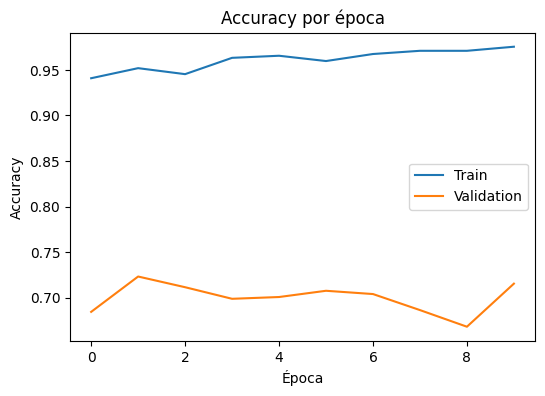

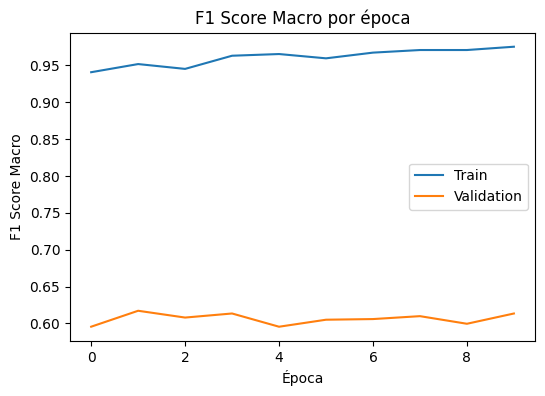

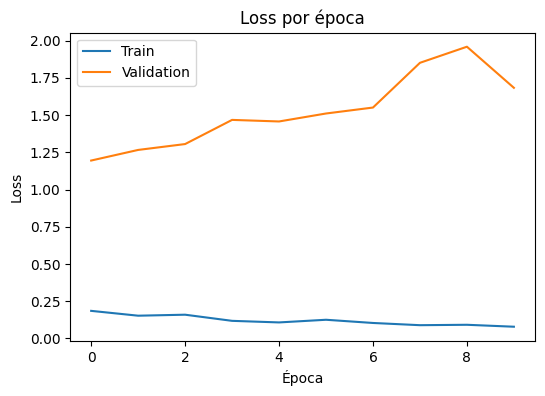

In [28]:
# graficamos la evolución de las métricas durante el entrenamiento

plt.figure(figsize=(6, 4))
plt.plot(train_accuracies, label='Train')
plt.plot(val_accuracies, label='Validation')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Accuracy por época')
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(train_f1_scores, label='Train')
plt.plot(val_f1_scores, label='Validation')
plt.xlabel('Época')
plt.ylabel('F1 Score Macro')
plt.title('F1 Score Macro por época')
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Loss por época')
plt.legend()
plt.show()

#### Classification Report

In [33]:
from sklearn.metrics import classification_report

# obtenemos las predicciones del modelo sobre el conjunto de validación

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(
    all_labels,
    all_predictions,
    target_names=val_dataset.classes
))

              precision    recall  f1-score   support

     alegria       0.87      0.84      0.85      1185
    disgusto       0.36      0.35      0.36       160
       enojo       0.54      0.69      0.61       162
       miedo       0.41      0.55      0.47        74
    seriedad       0.65      0.76      0.70       680
    sorpresa       0.72      0.74      0.73       329
    tristeza       0.70      0.50      0.58       478

    accuracy                           0.72      3068
   macro avg       0.61      0.63      0.61      3068
weighted avg       0.72      0.72      0.72      3068



#### Matriz de confusión absoluta

In [35]:
from sklearn.metrics import confusion_matrix

# matriz de confusión absoluta
cm = confusion_matrix(all_labels, all_predictions)

print("Matriz de confusión absoluta:")
print(cm)

Matriz de confusión absoluta:
[[992  22  22  17  70  19  43]
 [ 13  56  18   1  47  13  12]
 [ 19   7 111   4  13   6   2]
 [  6   3   6  41   5   9   4]
 [ 39  37   9   5 515  38  37]
 [ 12   4  12  19  34 242   6]
 [ 55  26  26  13 110  10 238]]


#### Matriz de confusión normalizada

In [42]:
import numpy as np

# normalizamos la matriz de confusión por fila
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

print(cm_normalized)

[[0.8371308  0.0185654  0.0185654  0.01434599 0.05907173 0.01603376
  0.03628692]
 [0.08125    0.35       0.1125     0.00625    0.29375    0.08125
  0.075     ]
 [0.11728395 0.04320988 0.68518519 0.02469136 0.08024691 0.03703704
  0.01234568]
 [0.08108108 0.04054054 0.08108108 0.55405405 0.06756757 0.12162162
  0.05405405]
 [0.05735294 0.05441176 0.01323529 0.00735294 0.75735294 0.05588235
  0.05441176]
 [0.03647416 0.01215805 0.03647416 0.05775076 0.10334347 0.73556231
  0.01823708]
 [0.11506276 0.05439331 0.05439331 0.02719665 0.23012552 0.0209205
  0.49790795]]


 #### 4. Prueba de Imágenes Nuevas (1 punto)
Subir al menos 12 imágenes personales de cualquier ratio o relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación. Tampoco vale usar imágenes de otro dataset, deben ser imágenes sueltas.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones que durante el entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

Búsqueda de imágenes

In [68]:
import os

ruta_imagenes = "imagenes"

imagenes = os.listdir(ruta_imagenes)

print(f"Cantidad de imágenes: {len(imagenes)}")

print(imagenes)

Cantidad de imágenes: 14
['Disgusto2.jfif', 'Miedo2.jfif', 'Tristeza1.jfif', 'Enojo1.jfif', 'Alegria2.jfif', 'Sorpresa2.jfif', 'Disgusto1.jfif', 'Alegria1.jfif', 'Seriedad2.jfif', 'Sorpresa1.jfif', 'Enojo2.jfif', 'Tristeza2.jfif', 'Seriedad1.jfif', 'Miedo1.jfif']


Preprocesamiento

In [69]:
from torchvision import transforms

# adaptamos las imágenes nuevas al tamaño de entrada del modelo
# y mantenemos el mismo preprocesamiento utilizado en validation
transform_nuevas = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean], std=[std])
])

Procesamiento de imágenes

In [70]:
from PIL import Image

imagenes_procesadas = []

for nombre in imagenes:
    ruta = os.path.join(ruta_imagenes, nombre)

    imagen = Image.open(ruta).convert("RGB")
    imagen_procesada = transform_nuevas(imagen)

    imagenes_procesadas.append((nombre, imagen, imagen_procesada))

print(f"Imágenes procesadas: {len(imagenes_procesadas)}")

Imágenes procesadas: 14


Predicciones

In [71]:
import torch.nn.functional as F

model.eval()

resultados = []

with torch.no_grad():
    for nombre, imagen, imagen_procesada in imagenes_procesadas:
        entrada = imagen_procesada.unsqueeze(0).to(device)

        outputs = model(entrada)
        probabilidades = F.softmax(outputs, dim=1)

        clase = probabilidades.argmax(dim=1).item()
        score = probabilidades[0, clase].item()

        resultados.append({
            "nombre": nombre,
            "imagen": imagen,
            "imagen_procesada": imagen_procesada,
            "probabilidades": probabilidades[0].cpu().numpy(),
            "clase": val_dataset.classes[clase],
            "score": score
        })

print(f"Predicciones realizadas: {len(resultados)}")

Predicciones realizadas: 14


Resultados

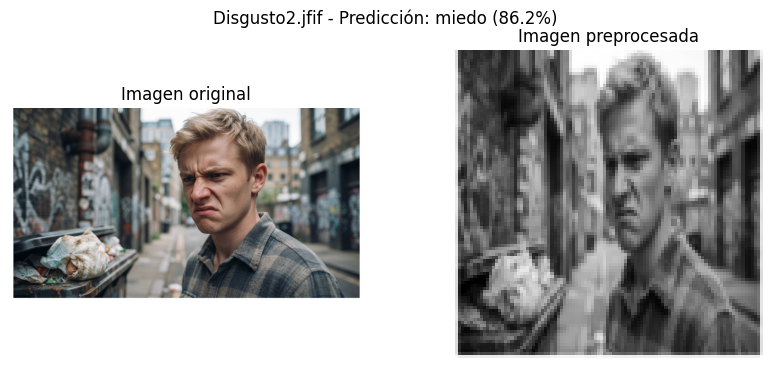

Scores por clase:
  alegria: 0.00%
  disgusto: 0.00%
  enojo: 0.27%
  miedo: 86.16%
  seriedad: 0.75%
  sorpresa: 9.41%
  tristeza: 3.42%



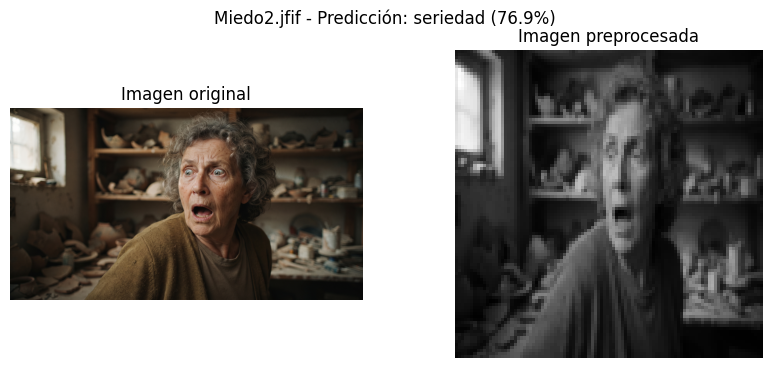

Scores por clase:
  alegria: 0.00%
  disgusto: 0.10%
  enojo: 21.57%
  miedo: 0.01%
  seriedad: 76.94%
  sorpresa: 1.38%
  tristeza: 0.00%



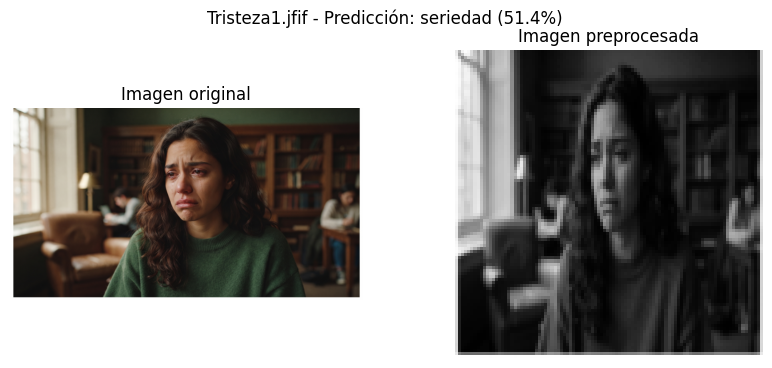

Scores por clase:
  alegria: 0.40%
  disgusto: 0.44%
  enojo: 13.29%
  miedo: 0.16%
  seriedad: 51.41%
  sorpresa: 30.10%
  tristeza: 4.21%



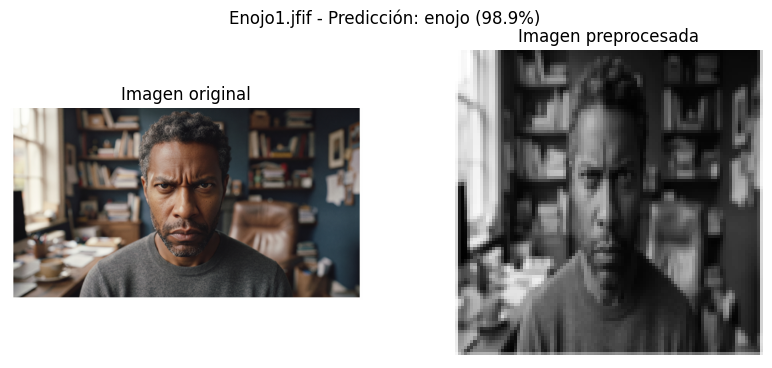

Scores por clase:
  alegria: 0.00%
  disgusto: 0.00%
  enojo: 98.88%
  miedo: 1.02%
  seriedad: 0.00%
  sorpresa: 0.00%
  tristeza: 0.11%



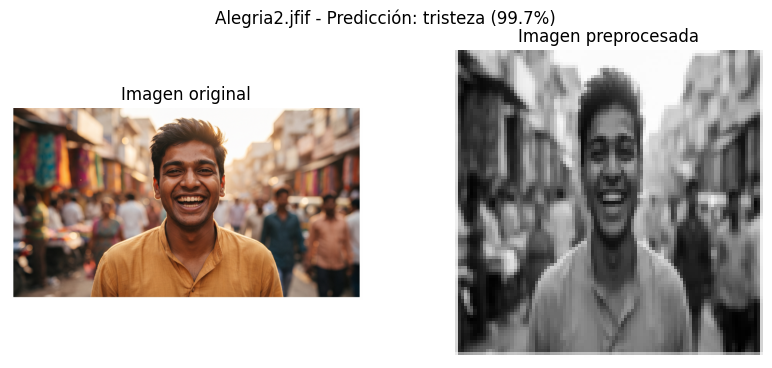

Scores por clase:
  alegria: 0.00%
  disgusto: 0.00%
  enojo: 0.28%
  miedo: 0.00%
  seriedad: 0.00%
  sorpresa: 0.01%
  tristeza: 99.71%



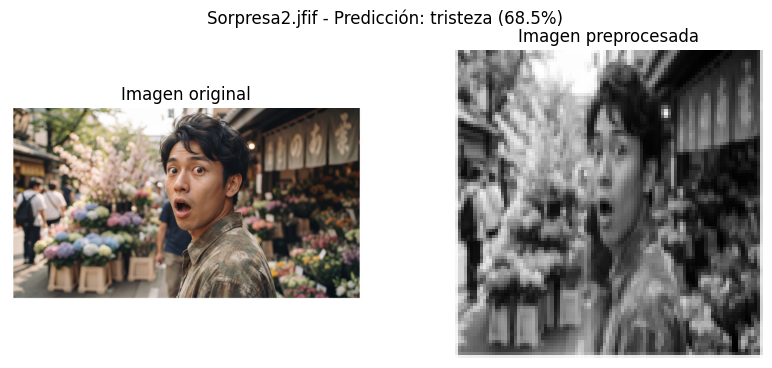

Scores por clase:
  alegria: 0.00%
  disgusto: 0.01%
  enojo: 0.94%
  miedo: 28.12%
  seriedad: 2.41%
  sorpresa: 0.00%
  tristeza: 68.53%



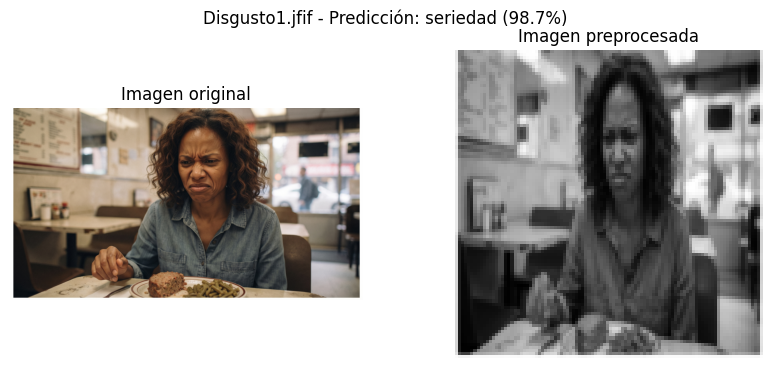

Scores por clase:
  alegria: 0.00%
  disgusto: 0.00%
  enojo: 0.00%
  miedo: 0.00%
  seriedad: 98.73%
  sorpresa: 0.00%
  tristeza: 1.27%



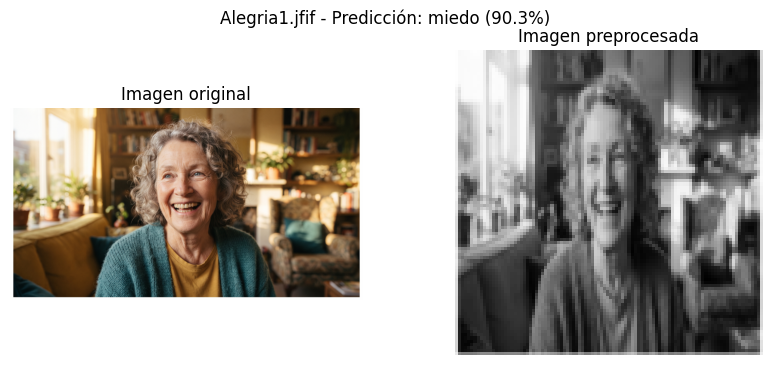

Scores por clase:
  alegria: 0.00%
  disgusto: 0.00%
  enojo: 0.00%
  miedo: 90.30%
  seriedad: 9.70%
  sorpresa: 0.00%
  tristeza: 0.00%



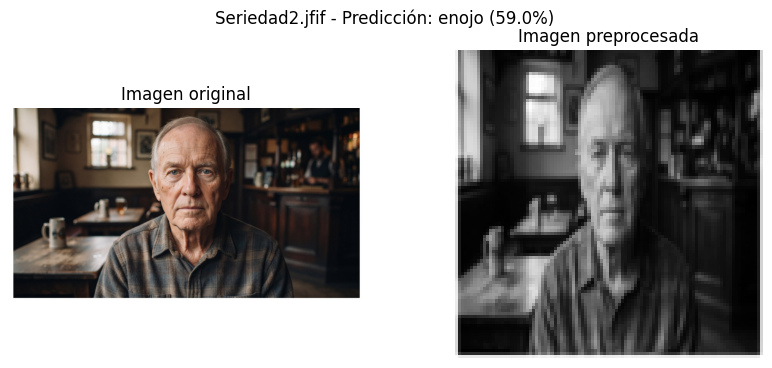

Scores por clase:
  alegria: 0.00%
  disgusto: 0.01%
  enojo: 59.00%
  miedo: 0.39%
  seriedad: 38.09%
  sorpresa: 0.58%
  tristeza: 1.92%



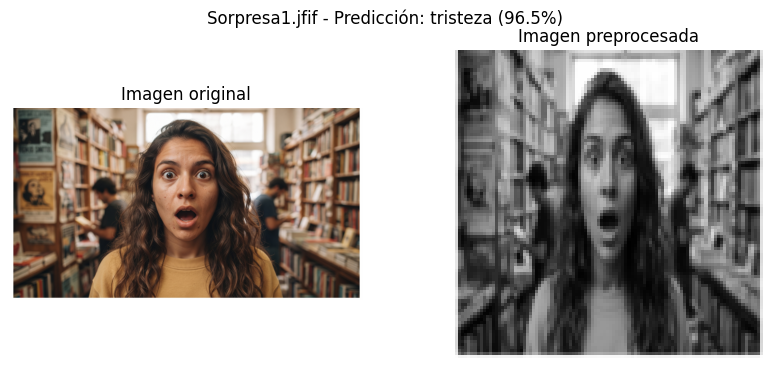

Scores por clase:
  alegria: 0.00%
  disgusto: 0.00%
  enojo: 0.00%
  miedo: 3.43%
  seriedad: 0.00%
  sorpresa: 0.08%
  tristeza: 96.49%



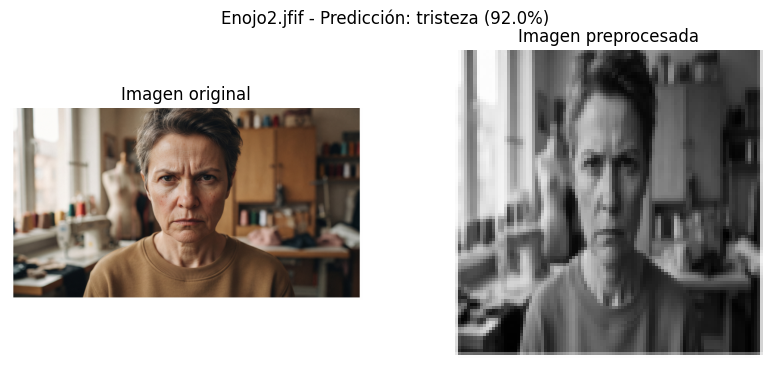

Scores por clase:
  alegria: 0.00%
  disgusto: 0.00%
  enojo: 7.97%
  miedo: 0.00%
  seriedad: 0.00%
  sorpresa: 0.00%
  tristeza: 92.02%



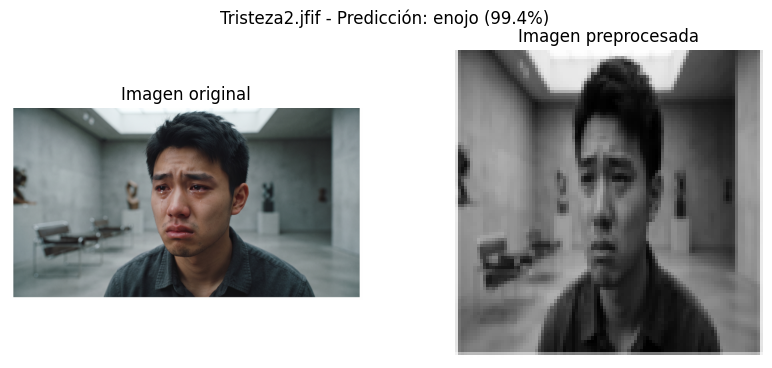

Scores por clase:
  alegria: 0.00%
  disgusto: 0.00%
  enojo: 99.41%
  miedo: 0.00%
  seriedad: 0.01%
  sorpresa: 0.00%
  tristeza: 0.58%



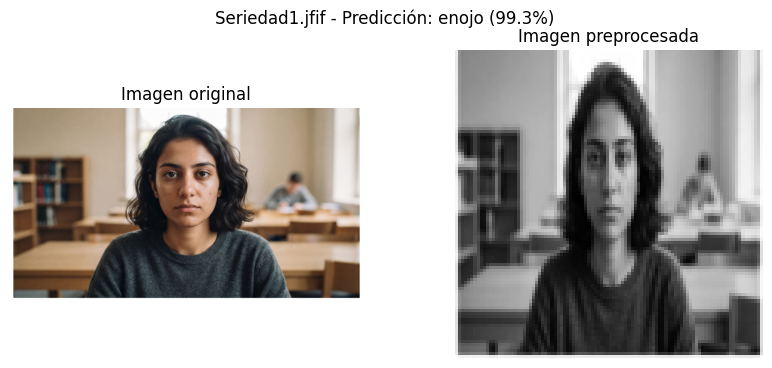

Scores por clase:
  alegria: 0.02%
  disgusto: 0.00%
  enojo: 99.26%
  miedo: 0.02%
  seriedad: 0.00%
  sorpresa: 0.00%
  tristeza: 0.70%



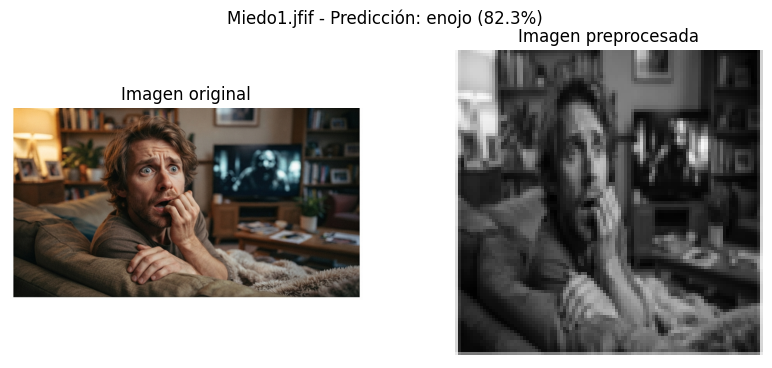

Scores por clase:
  alegria: 0.00%
  disgusto: 0.00%
  enojo: 82.33%
  miedo: 1.63%
  seriedad: 12.64%
  sorpresa: 2.75%
  tristeza: 0.65%



In [72]:
import matplotlib.pyplot as plt

for resultado in resultados:
    probabilidades = resultado["probabilidades"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # imagen original
    axes[0].imshow(resultado["imagen"])
    axes[0].set_title("Imagen original")
    axes[0].axis("off")

    # imagen preprocesada
    axes[1].imshow(resultado["imagen_procesada"].squeeze(), cmap="gray")
    axes[1].set_title("Imagen preprocesada")
    axes[1].axis("off")

    plt.suptitle(
        f"{resultado['nombre']} - "
        f"Predicción: {resultado['clase']} "
        f"({resultado['score']*100:.1f}%)"
    )

    plt.show()

    print("Scores por clase:")
    for clase, probabilidad in zip(val_dataset.classes, probabilidades):
        print(f"  {clase}: {probabilidad*100:.2f}%")

    print()

 #### 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 12 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase esperada
  - La clase ganadora inferida por el modelo

- Analizar los casos en los que el modelo se equivoca e intentar identificar posibles causas, tales como:

  - Similitudes entre emociones.
  - Mezcla de 2 o más emociones en una misma expresión.

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

**IMPORTANTE:** Ajusten los parámetros `scaleFactor`, `minNeighbors` y `minSize` según convenga para que la detección de rostros sea más efectiva y logre detectar rostros en sus 12 imágenes. No se queden necesariamente con los valores por defecto.

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

image_path = ""

image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6, minSize=(30,30))

image_with_box = image.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(image_with_box, (x, y), (x + w, y + h), (0, 255, 0), 2)

cropped_face_rgb = None
if len(faces) > 0:
    (x, y, w, h) = faces[0]
    center_x, center_y = x + w // 2, y + h // 2
    side = max(w, h)
    half_side = side // 2

    x1 = max(center_x - half_side, 0)
    y1 = max(center_y - half_side, 0)
    x2 = min(center_x + half_side, image.shape[1])
    y2 = min(center_y + half_side, image.shape[0])

    cropped_face = image[y1:y2, x1:x2]
    cropped_face_rgb = cv2.cvtColor(cropped_face, cv2.COLOR_BGR2RGB)

image_with_box_rgb = cv2.cvtColor(image_with_box, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_with_box_rgb)
ax[0].set_title("Detección")
ax[0].axis('off')

if cropped_face_rgb is not None:
    ax[1].imshow(cropped_face_rgb)
    ax[1].set_title("Rostro recortado (relación aspecto 1:1)")
    ax[1].axis('off')
else:
    ax[1].text(0.5, 0.5, 'No se detectó rostro', horizontalalignment='center', verticalalignment='center')
    ax[1].axis('off')

plt.tight_layout()
plt.show()

error: OpenCV(4.14.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'
